# 1
Load the data into a data frame with the proper coding of nulls, renamethe columns to numbers starting from 1, as shown in the description file.
Remove columns named3, 25, 26, 27, 28.Explore the data.
Show the count of nulls for each remaining column.

In [47]:
import pandas as pd
data = pd.read_csv("./horse-colic.csv", header=None, na_values="?")
data.rename(columns={c:c+1 for c in data.columns}, inplace=True)

data.drop(columns=[3, 25, 26, 27, 28], inplace=True, axis=1)

display(data.head())

nulls_report = {"Column":[], "Tot nulls":[]}
for c in data.columns:
    nulls_report["Column"].append(c)
    nulls_report["Tot nulls"].append(len(data[c])-len(data[c].dropna()))
pd.DataFrame(nulls_report)

,1,2,4,5,6,7,8,9,10,11,...,15,16,17,18,19,20,21,22,23,24
0,2.0,1,38.5,66.0,28.0,3.0,3.0,NaN,2.0,5.0,...,NaN,NaN,3.0,5.0,45.0,8.4,NaN,NaN,2.0,2
1,1.0,1,39.2,88.0,20.0,NaN,NaN,4.0,1.0,3.0,...,NaN,NaN,4.0,2.0,50.0,85.0,2.0,2.0,3.0,2
2,2.0,1,38.3,40.0,24.0,1.0,1.0,3.0,1.0,3.0,...,NaN,NaN,1.0,1.0,33.0,6.7,NaN,NaN,1.0,2
3,1.0,9,39.1,164.0,84.0,4.0,1.0,6.0,2.0,2.0,...,2.0,5.0,3.0,NaN,48.0,7.2,3.0,5.3,2.0,1
4,2.0,1,37.3,104.0,35.0,NaN,NaN,6.0,2.0,NaN,...,NaN,NaN,NaN,NaN,74.0,7.4,NaN,NaN,2.0,2


,Column,Tot nulls
0,1,1
1,2,0
2,4,60
3,5,24
4,6,58
5,7,56
6,8,69
7,9,47
8,10,32
9,11,55


# 2) Use column23as target for classification.  Drop the rows where thetarget is null.Impute the nulls on the predicting columns using the column means(you can use thesklearn.impute.SimpleImputer)Separe the dataset into thepredictingandtargetpartsX, y

In [48]:
df_imputed.columns

Index([ 1,  2,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,
       20, 21, 22, 23, 24],
      dtype='int64')

In [ ]:
index_to_drop = [i for i in range(len(data[23])) if pd.isna(data.loc[i, 23])]
df_cleaned = data.drop(index=index_to_drop)

from sklearn.impute import SimpleImputer
imputer = SimpleImputer()
df_imputed = pd.DataFrame(imputer.fit_transform(df_cleaned), columns=df_cleaned.columns)

y = df_imputed[23]
X = df_imputed.drop(columns=[23], axis=1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 22 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   1       299 non-null    float64
 1   2       299 non-null    float64
 2   4       299 non-null    float64
 3   5       299 non-null    float64
 4   6       299 non-null    float64
 5   7       299 non-null    float64
 6   8       299 non-null    float64
 7   9       299 non-null    float64
 8   10      299 non-null    float64
 9   11      299 non-null    float64
 10  12      299 non-null    float64
 11  13      299 non-null    float64
 12  14      299 non-null    float64
 13  15      299 non-null    float64
 14  16      299 non-null    float64
 15  17      299 non-null    float64
 16  18      299 non-null    float64
 17  19      299 non-null    float64
 18  20      299 non-null    float64
 19  21      299 non-null    float64
 20  22      299 non-null    float64
 21  24      299 non-null    float64
dtypes:

# 3-4
Train, tune and test a classification model of your choice withcross–validationPlot the resulting confusion matrix on the test set, normalising for truevalues.Show the valuesF1-Score(macro) andCohen Kappa Scoreon the testset.

For model Decision Tree:
Best parameters: {'criterion': 'gini', 'max_depth': 6, 'splitter': 'random'}


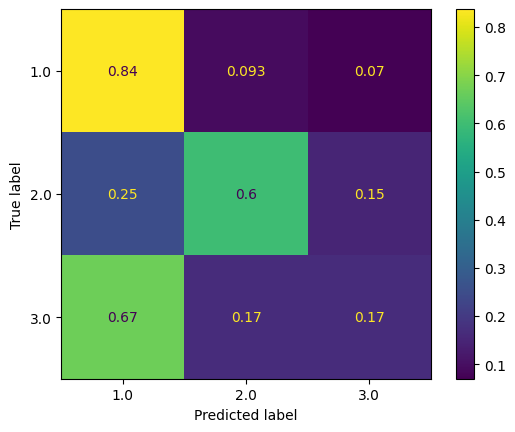

On the test the F1-score macro is 0.5380625476735317
On the test the Cohen Kappa Score is 0.38765512736773355
For model Random Forest:
Best parameters: {'criterion': 'gini', 'max_depth': 20, 'n_estimators': 30}


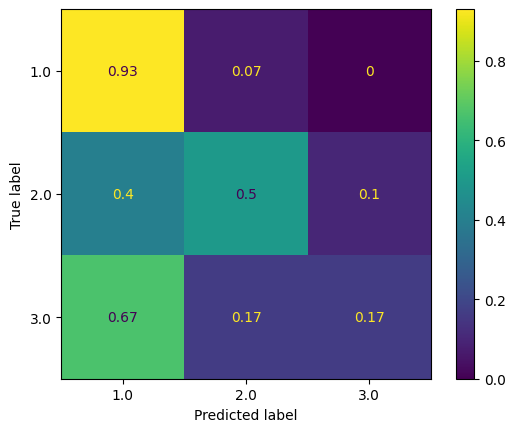

On the test the F1-score macro is 0.5431697931697932
On the test the Cohen Kappa Score is 0.3987452073893343


In [54]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, cohen_kappa_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

random_state = 42

X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=random_state)

models = {
    "dt" : {
        "name" : "Decision Tree",
        "estimator" : DecisionTreeClassifier(random_state=random_state),
        "params" : {
            "max_depth" : [*range(1,21)],
            "criterion" : ["gini", "entropy", "log_loss"],
            "splitter" : ["best", "random"]
        }
    },
    "rf" : {
        "name" : "Random Forest",
        "estimator" : RandomForestClassifier(random_state=random_state, n_jobs=-1),
        "params" : {
            "n_estimators" : [*range(10,61,10)],
            "max_depth" : [*range(1,21)],
            "criterion" : ["gini", "entropy", "log_loss"]
        }
    }
}

for k, model in models.items():
    print("="*80)
    print(f"For model {model['name']}:")
    
    gscv = GridSearchCV(
        estimator=model["estimator"],
        param_grid=model["params"],
        n_jobs=-1,
        scoring="accuracy", error_score='raise'
    ).fit(X_train, y_train)
    best_params = gscv.best_params_
    print(f"Best parameters: {best_params}")
    
    best_model = model["estimator"].set_params(**best_params).fit(X_train, y_train)
    y_pred = best_model.predict(X_test)
    
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred, normalize="true"),
        display_labels=np.unique(y_test)
    ).plot()
    plt.show()
    
    print(f"On the test the F1-score macro is {f1_score(y_test, y_pred, average='macro')}")
    print(f"On the test the Cohen Kappa Score is {cohen_kappa_score(y_test, y_pred)}")
    

In both the classifiers the Cohen Kappa Score is medium-high and positive so we can say that the agreement between two annotators is good.

The F1-score in both is medium and also the confusion matrix. 

Maybe using 2 more different models could have been useful ahahaha